In [1]:
%matplotlib inline

from pathlib import Path
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings('ignore')

try:
    import dask.dataframe as dd
    from distributed import Client, LocalCluster
    DASK_AVAILABLE = True
except Exception:
    DASK_AVAILABLE = False

BIG_FILE = 'Trips_by_Distance.csv'
SMALL_FILE = 'Trips_Full Data.csv'

DISTANCE_COLUMNS = {
    'Trips <1 Mile': 0.5,
    'Trips 1-3 Miles': 2.0,
    'Trips 3-5 Miles': 4.0,
    'Trips 5-10 Miles': 7.5,
    'Trips 10-25 Miles': 17.5,
    'Trips 25-50 Miles': 37.5,
    'Trips 50-100 Miles': 75.0,
    'Trips 100-250 Miles': 175.0,
    'Trips 250-500 Miles': 375.0,
    'Trips 500+ Miles': 500.0,
}

In [2]:
def load_pandas_data(big_path: str = BIG_FILE, small_path: str = SMALL_FILE):
    big = pd.read_csv(big_path, low_memory=False)
    small = pd.read_csv(small_path, low_memory=False)
    return big, small


def clean_big_dataset(big: pd.DataFrame) -> pd.DataFrame:
    df = big.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    if 'Level' in df.columns:
        df = df[df['Level'] == 'National'].copy()

    df = df.sort_values('Date').reset_index(drop=True)

    numeric_cols = [
        'Population Staying at Home',
        'Population Not Staying at Home',
        'Number of Trips',
        'Number of Trips <1',
        'Number of Trips 1-3',
        'Number of Trips 3-5',
        'Number of Trips 5-10',
        'Number of Trips 10-25',
        'Number of Trips 25-50',
        'Number of Trips 50-100',
        'Number of Trips 100-250',
        'Number of Trips 250-500',
        'Number of Trips >=500',
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].mean())

    if 'Week' in df.columns:
        df['Week'] = pd.to_numeric(df['Week'], errors='coerce')
    else:
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

    df = df.drop_duplicates().reset_index(drop=True)
    return df


def clean_small_dataset(small: pd.DataFrame) -> pd.DataFrame:
    df = small.copy()
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    if 'Level' in df.columns:
        df = df[df['Level'] == 'National'].copy()

    df = df.sort_values('Date').reset_index(drop=True)

    for col in DISTANCE_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].mean())

    keep_numeric = [
        'Trips',
        'People Not Staying at Home',
        'Population Staying at Home',
        'Trips 1-25 Miles',
        'Trips 100+ Miles'
    ]

    for col in keep_numeric:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].mean())

    df = df.drop_duplicates().reset_index(drop=True)
    return df


def build_long_distance_dataframe(small_df: pd.DataFrame) -> pd.DataFrame:
    long_df = small_df.melt(
        id_vars=['Date'],
        value_vars=list(DISTANCE_COLUMNS.keys()),
        var_name='distance_band',
        value_name='trips'
    )
    long_df['distance_midpoint'] = long_df['distance_band'].map(DISTANCE_COLUMNS)
    long_df['trips'] = pd.to_numeric(long_df['trips'], errors='coerce')
    long_df = long_df.dropna().reset_index(drop=True)
    return long_df

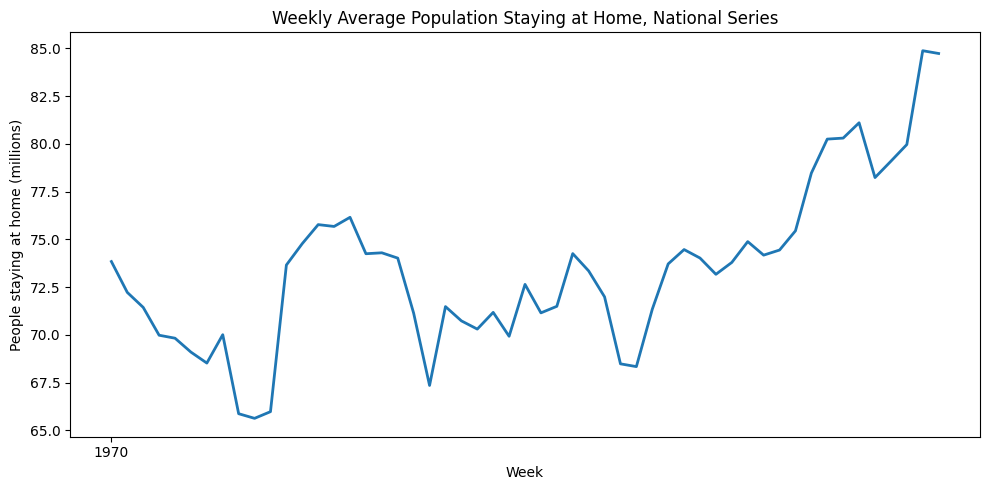

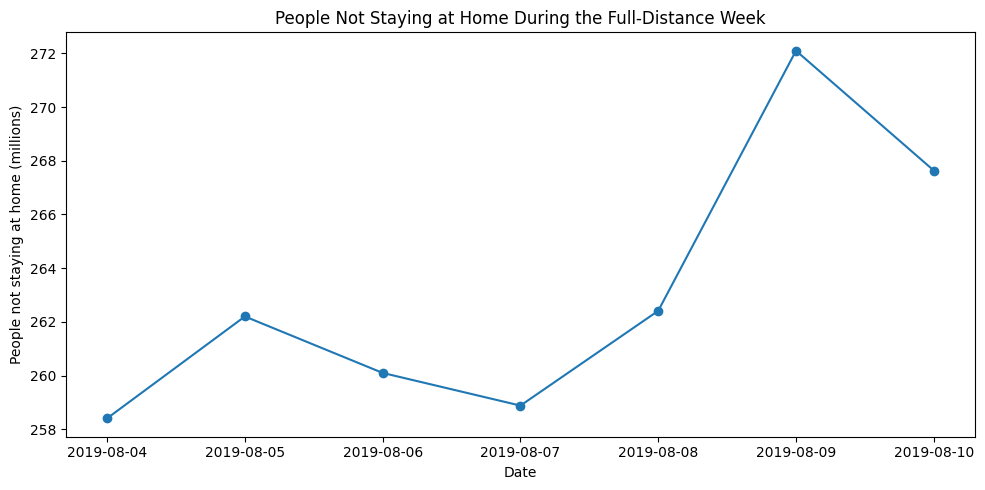

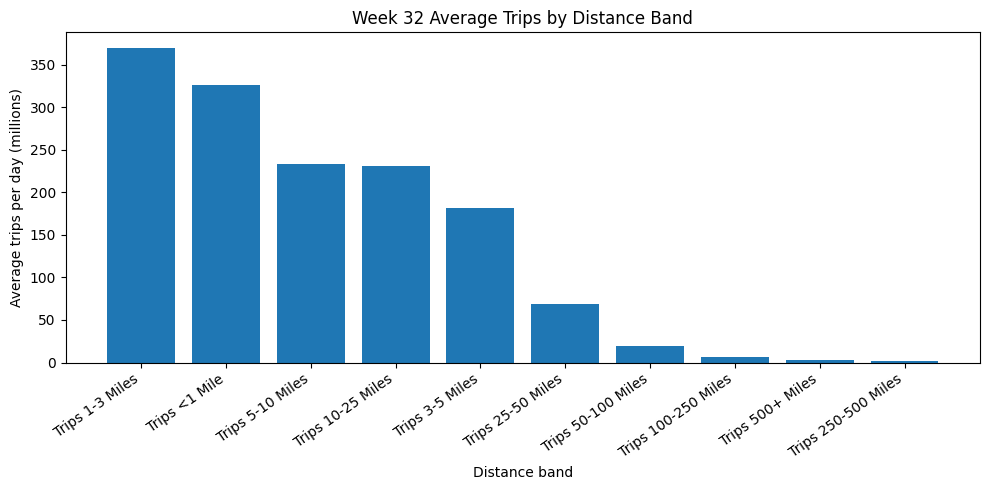

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def question_1(big_df: pd.DataFrame, small_df: pd.DataFrame):
    big_df = big_df.copy()
    small_df = small_df.copy()

    big_df['Week'] = pd.to_datetime(big_df['Week'])
    small_df['Date'] = pd.to_datetime(small_df['Date'])

    weekly_home = (
        big_df.groupby('Week', as_index=False)['Population Staying at Home']
        .mean()
        .rename(columns={'Population Staying at Home': 'avg_population_staying_home'})
        .sort_values('Week')
    )

    daily_not_home = (
        small_df[['Date', 'People Not Staying at Home']]
        .copy()
        .sort_values('Date')
    )

    week_32_trips = (
        small_df[list(DISTANCE_COLUMNS.keys())]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    week_32_trips.columns = ['distance_band', 'avg_trips']

    return weekly_home, daily_not_home, week_32_trips


def plot_question_1(
    weekly_home: pd.DataFrame,
    daily_not_home: pd.DataFrame,
    week_32_trips: pd.DataFrame
):
    plt.figure(figsize=(10, 5))
    plt.plot(
        weekly_home['Week'],
        weekly_home['avg_population_staying_home'] / 1_000_000,
        linewidth=2
    )
    plt.xlabel('Week')
    plt.ylabel('People staying at home (millions)')
    plt.title('Weekly Average Population Staying at Home, National Series')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(
        daily_not_home['Date'],
        daily_not_home['People Not Staying at Home'] / 1_000_000,
        marker='o'
    )
    plt.xlabel('Date')
    plt.ylabel('People not staying at home (millions)')
    plt.title('People Not Staying at Home During the Full-Distance Week')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(
        week_32_trips['distance_band'],
        week_32_trips['avg_trips'] / 1_000_000
    )
    plt.xlabel('Distance band')
    plt.ylabel('Average trips per day (millions)')
    plt.title('Week 32 Average Trips by Distance Band')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()


big_df, small_df = load_pandas_data(BIG_FILE, SMALL_FILE)
big_df = clean_big_dataset(big_df)
small_df = clean_small_dataset(small_df)

weekly_home, daily_not_home, week_32_trips = question_1(big_df, small_df)
plot_question_1(weekly_home, daily_not_home, week_32_trips)

                   condition  count
0   10-25 trips > 10,000,000    901
1  50-100 trips > 10,000,000    900
2       Both conditions true    900


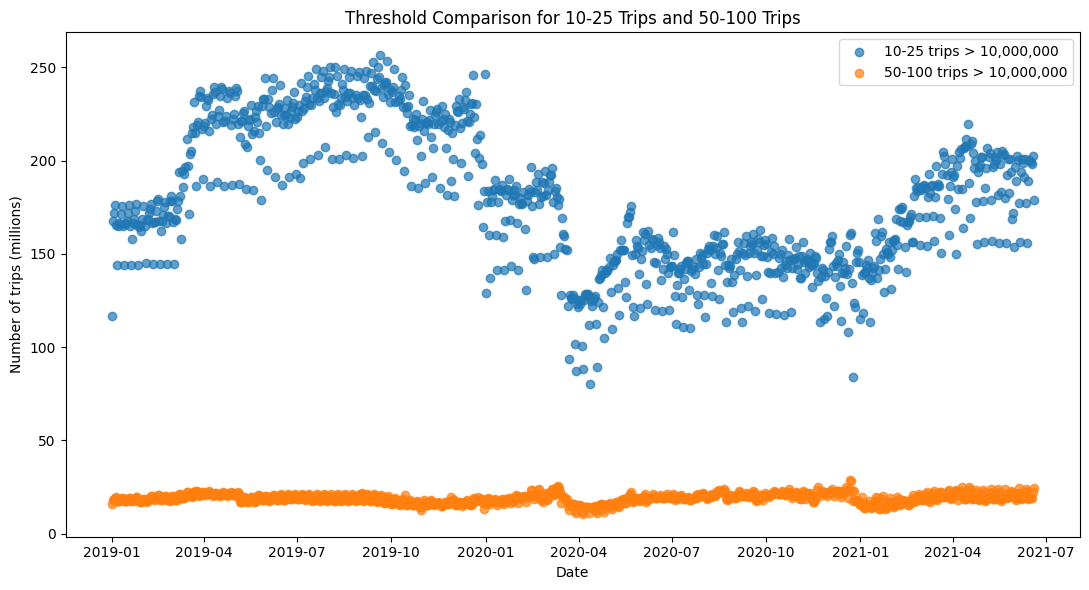

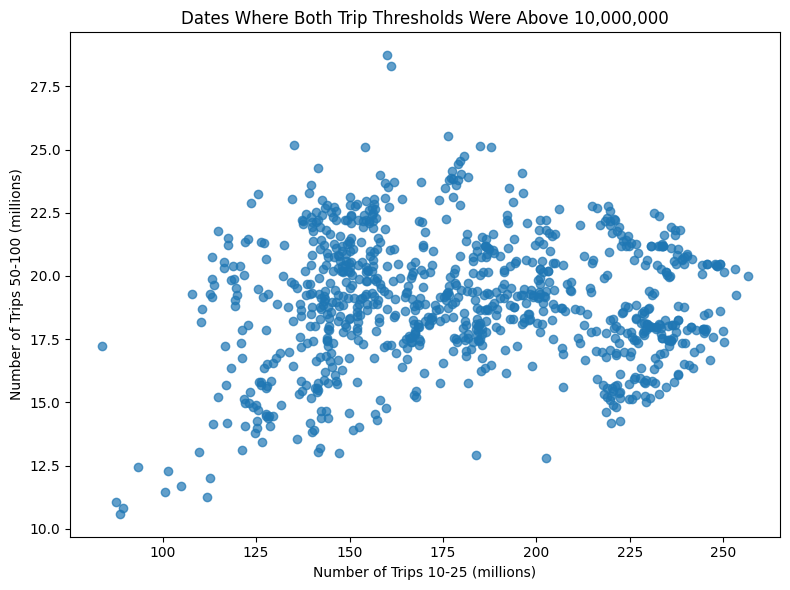

In [4]:
def question_2(big_df: pd.DataFrame):
    threshold = 10_000_000
    filtered = big_df[['Date', 'Number of Trips 10-25', 'Number of Trips 50-100']].copy()

    filtered['Date'] = pd.to_datetime(filtered['Date'])

    over_10_25 = filtered[filtered['Number of Trips 10-25'] > threshold].copy()
    over_50_100 = filtered[filtered['Number of Trips 50-100'] > threshold].copy()
    both = filtered[
        (filtered['Number of Trips 10-25'] > threshold) &
        (filtered['Number of Trips 50-100'] > threshold)
    ].copy()

    summary = pd.DataFrame({
        'condition': [
            '10-25 trips > 10,000,000',
            '50-100 trips > 10,000,000',
            'Both conditions true'
        ],
        'count': [len(over_10_25), len(over_50_100), len(both)]
    })

    return over_10_25, over_50_100, both, summary


def plot_question_2(over_10_25: pd.DataFrame, over_50_100: pd.DataFrame, both: pd.DataFrame):
    plt.figure(figsize=(11, 6))
    plt.scatter(
        over_10_25['Date'],
        over_10_25['Number of Trips 10-25'] / 1_000_000,
        alpha=0.7,
        label='10-25 trips > 10,000,000'
    )
    plt.scatter(
        over_50_100['Date'],
        over_50_100['Number of Trips 50-100'] / 1_000_000,
        alpha=0.7,
        label='50-100 trips > 10,000,000'
    )
    plt.xlabel('Date')
    plt.ylabel('Number of trips (millions)')
    plt.title('Threshold Comparison for 10-25 Trips and 50-100 Trips')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(
        both['Number of Trips 10-25'] / 1_000_000,
        both['Number of Trips 50-100'] / 1_000_000,
        alpha=0.7
    )
    plt.xlabel('Number of Trips 10-25 (millions)')
    plt.ylabel('Number of Trips 50-100 (millions)')
    plt.title('Dates Where Both Trip Thresholds Were Above 10,000,000')
    plt.tight_layout()
    plt.show()


big_df, small_df = load_pandas_data(BIG_FILE, SMALL_FILE)
big_df = clean_big_dataset(big_df)
small_df = clean_small_dataset(small_df)

over_10_25, over_50_100, both, q2_summary = question_2(big_df)
print(q2_summary)
plot_question_2(over_10_25, over_50_100, both)

                              model          rmse        r2
0  Polynomial Regression (degree 2)  8.035909e+07  0.691822
1                 Linear Regression  1.058043e+08  0.465758


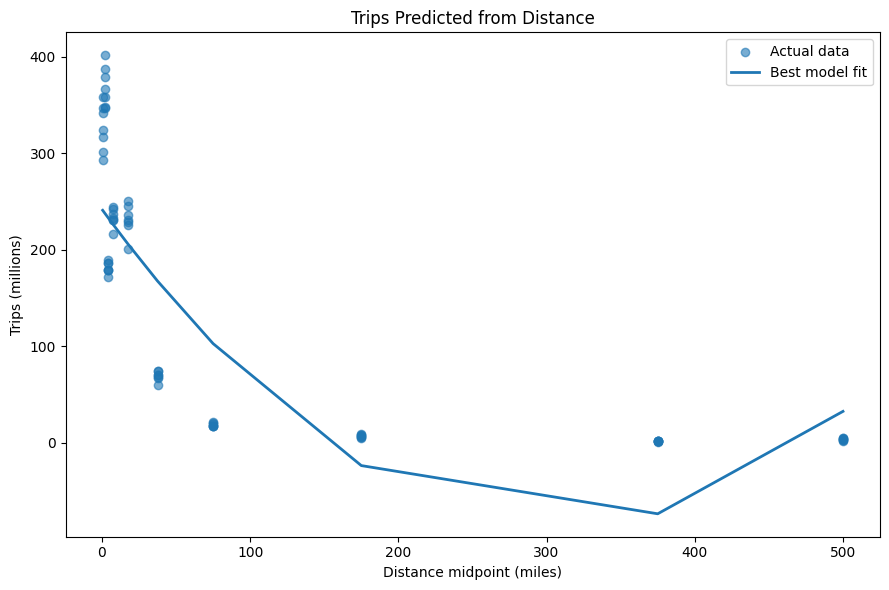

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


def question_3(small_df: pd.DataFrame):

    long_df = build_long_distance_dataframe(small_df)

    X = long_df[['distance_midpoint']]
    y = long_df['trips']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42
    )

    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    linear_pred = linear_model.predict(X_test)

    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', LinearRegression())
    ])

    poly_model.fit(X_train, y_train)
    poly_pred = poly_model.predict(X_test)

    metrics = pd.DataFrame([
        {
            'model': 'Linear Regression',
            'rmse': mean_squared_error(y_test, linear_pred) ** 0.5,
            'r2': r2_score(y_test, linear_pred)
        },
        {
            'model': 'Polynomial Regression (degree 2)',
            'rmse': mean_squared_error(y_test, poly_pred) ** 0.5,
            'r2': r2_score(y_test, poly_pred)
        }
    ]).sort_values('rmse').reset_index(drop=True)

    best_model_name = metrics.loc[0, 'model']

    if 'Polynomial' in best_model_name:
        best_model = poly_model
    else:
        best_model = linear_model

    plot_df = long_df.sort_values('distance_midpoint').copy()

    x_plot = plot_df[['distance_midpoint']]
    plot_df['best_model_prediction'] = best_model.predict(x_plot)

    return long_df, metrics, plot_df


def plot_question_3(long_df: pd.DataFrame, plot_df: pd.DataFrame):

    plt.figure(figsize=(9, 6))

    plt.scatter(
        long_df['distance_midpoint'],
        long_df['trips'] / 1_000_000,
        alpha=0.6,
        label='Actual data'
    )

    plt.plot(
        plot_df['distance_midpoint'],
        plot_df['best_model_prediction'] / 1_000_000,
        linewidth=2,
        label='Best model fit'
    )

    plt.xlabel('Distance midpoint (miles)')
    plt.ylabel('Trips (millions)')
    plt.title('Trips Predicted from Distance')

    plt.legend()
    plt.tight_layout()
    plt.show()

big_df, small_df = load_pandas_data(BIG_FILE, SMALL_FILE)
big_df = clean_big_dataset(big_df)
small_df = clean_small_dataset(small_df)

long_df, metrics, plot_df = question_3(small_df)
print(metrics)
plot_question_3(long_df, plot_df)

         distance_band  average_travellers
0      Trips 1-3 Miles        3.694767e+08
1        Trips <1 Mile        3.259764e+08
2     Trips 5-10 Miles        2.334445e+08
3    Trips 10-25 Miles        2.310785e+08
4      Trips 3-5 Miles        1.815558e+08
5    Trips 25-50 Miles        6.915913e+07
6   Trips 50-100 Miles        1.887832e+07
7  Trips 100-250 Miles        6.850130e+06
8     Trips 500+ Miles        3.443101e+06
9  Trips 250-500 Miles        1.829242e+06


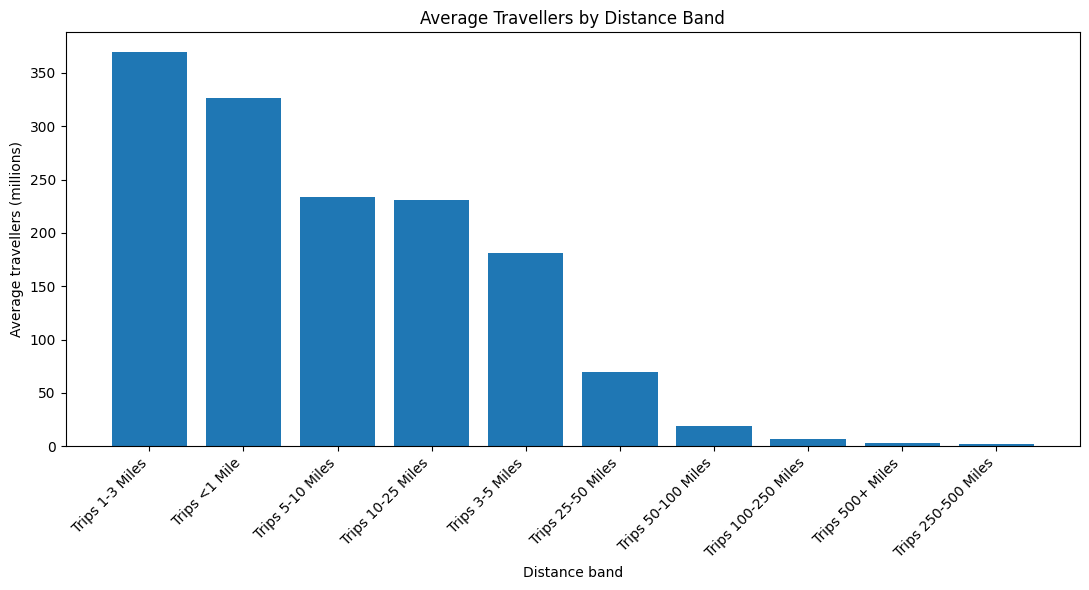

In [6]:
def question_4(small_df: pd.DataFrame):
    avg_travellers_by_distance = (
        small_df[list(DISTANCE_COLUMNS.keys())]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    avg_travellers_by_distance.columns = ['distance_band', 'average_travellers']
    return avg_travellers_by_distance


def plot_question_4(avg_travellers_by_distance: pd.DataFrame):
    plt.figure(figsize=(11, 6))
    plt.bar(
        avg_travellers_by_distance['distance_band'],
        avg_travellers_by_distance['average_travellers'] / 1_000_000
    )
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Distance band')
    plt.ylabel('Average travellers (millions)')
    plt.title('Average Travellers by Distance Band')
    plt.tight_layout()
    plt.show()


big_df, small_df = load_pandas_data(BIG_FILE, SMALL_FILE)
big_df = clean_big_dataset(big_df)
small_df = clean_small_dataset(small_df)

avg_travellers_by_distance = question_4(small_df)
print(avg_travellers_by_distance)
plot_question_4(avg_travellers_by_distance)

In [7]:
def run_serial(big_df: pd.DataFrame, small_df: pd.DataFrame):
    start = time.perf_counter()

    weekly_home, daily_not_home, mean_trips_by_distance = question_1(big_df, small_df)
    over_10_25, over_50_100, both, q2_summary = question_2(big_df)
    long_df, metrics, plot_df = question_3(small_df)
    avg_travellers_by_distance = question_4(small_df)

    elapsed = time.perf_counter() - start

    results = {
        'weekly_home': weekly_home,
        'daily_not_home': daily_not_home,
        'mean_trips_by_distance': mean_trips_by_distance,
        'over_10_25': over_10_25,
        'over_50_100': over_50_100,
        'both_thresholds': both,
        'q2_summary': q2_summary,
        'long_df': long_df,
        'model_metrics': metrics,
        'model_plot_df': plot_df,
        'avg_travellers_by_distance': avg_travellers_by_distance,
        'elapsed_seconds': elapsed,
    }

    return results

serial_results = run_serial(big_df, small_df)
print(serial_results['elapsed_seconds'])
print(serial_results['q2_summary'])
print(serial_results['model_metrics'])
print(serial_results['avg_travellers_by_distance'])

0.015536667022388428
                   condition  count
0   10-25 trips > 10,000,000    901
1  50-100 trips > 10,000,000    900
2       Both conditions true    900
                              model          rmse        r2
0  Polynomial Regression (degree 2)  8.035909e+07  0.691822
1                 Linear Regression  1.058043e+08  0.465758
         distance_band  average_travellers
0      Trips 1-3 Miles        3.694767e+08
1        Trips <1 Mile        3.259764e+08
2     Trips 5-10 Miles        2.334445e+08
3    Trips 10-25 Miles        2.310785e+08
4      Trips 3-5 Miles        1.815558e+08
5    Trips 25-50 Miles        6.915913e+07
6   Trips 50-100 Miles        1.887832e+07
7  Trips 100-250 Miles        6.850130e+06
8     Trips 500+ Miles        3.443101e+06
9  Trips 250-500 Miles        1.829242e+06


In [8]:
def run_parallel_with_dask(big_path: str, small_path: str, workers: int):
    if not DASK_AVAILABLE:
        raise ImportError('Dask is not installed. Run: pip install "dask[distributed]" pyarrow')

    cluster = LocalCluster(n_workers=workers, threads_per_worker=1, processes=True, dashboard_address=None)
    client = Client(cluster)

    try:
        start = time.perf_counter()

        big_dd = dd.read_csv(big_path, assume_missing=True, dtype=str)
        small_dd = dd.read_csv(small_path, assume_missing=True, dtype=str)

        big_dd['Date'] = dd.to_datetime(big_dd['Date'], errors='coerce')
        small_dd['Date'] = dd.to_datetime(small_dd['Date'], errors='coerce')

        big_numeric_cols = [
            'Week',
            'Population Staying at Home',
            'Number of Trips 10-25',
            'Number of Trips 50-100'
        ]

        for col in big_numeric_cols:
            if col in big_dd.columns:
                big_dd[col] = dd.to_numeric(big_dd[col], errors='coerce')

        small_numeric_cols = list(DISTANCE_COLUMNS.keys())
        for col in small_numeric_cols:
            if col in small_dd.columns:
                small_dd[col] = dd.to_numeric(small_dd[col], errors='coerce')

        national_dd = big_dd[big_dd['Level'] == 'National'][[
            'Date',
            'Week',
            'Population Staying at Home',
            'Number of Trips 10-25',
            'Number of Trips 50-100'
        ]]

        weekly_home = national_dd.groupby('Week')['Population Staying at Home'].mean().compute().reset_index()
        weekly_home.columns = ['Week', 'avg_population_staying_home']

        over_10_25 = national_dd[national_dd['Number of Trips 10-25'] > 10_000_000][['Date', 'Number of Trips 10-25']].compute()
        over_50_100 = national_dd[national_dd['Number of Trips 50-100'] > 10_000_000][['Date', 'Number of Trips 50-100']].compute()

        both = national_dd[
            (national_dd['Number of Trips 10-25'] > 10_000_000) &
            (national_dd['Number of Trips 50-100'] > 10_000_000)
        ][['Date', 'Number of Trips 10-25', 'Number of Trips 50-100']].compute()

        mean_trips_by_distance = small_dd[list(DISTANCE_COLUMNS.keys())].mean().compute().sort_values(ascending=False).reset_index()
        mean_trips_by_distance.columns = ['distance_band', 'mean_trips']

        small_pdf = small_dd.compute()
        small_pdf = clean_small_dataset(small_pdf)

        long_df, metrics, plot_df = question_3(small_pdf)
        avg_travellers_by_distance = question_4(small_pdf)

        elapsed = time.perf_counter() - start

        return {
            'workers': workers,
            'weekly_home': weekly_home,
            'over_10_25': over_10_25,
            'over_50_100': over_50_100,
            'both_thresholds': both,
            'mean_trips_by_distance': mean_trips_by_distance,
            'model_metrics': metrics,
            'avg_travellers_by_distance': avg_travellers_by_distance,
            'elapsed_seconds': elapsed,
        }

    finally:
        client.close()
        cluster.close()

parallel_10 = run_parallel_with_dask(BIG_FILE, SMALL_FILE, workers=10)
parallel_20 = run_parallel_with_dask(BIG_FILE, SMALL_FILE, workers=20)
serial_results = run_serial(big_df, small_df)

print(serial_results['elapsed_seconds'])
print(parallel_10['elapsed_seconds'])
print(parallel_20['elapsed_seconds'])

2026-03-30 15:38:54,843 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 291.52 MiB -- Worker memory limit: 409.60 MiB
2026-03-30 15:38:54,889 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 295.97 MiB -- Worker memory limit: 409.60 MiB
2026-03-30 15:38:56,441 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  Process memory: 343.61 MiB -- Worker memory limit: 409.60 MiB
2026-03-30 15:38:56,488 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  

KilledWorker: Attempted to run task ('read-csv-e012f5fa2d30074d61a5a6d84abdf4f4', 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:62400. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

Timing data:
    mode  elapsed_seconds
  Serial             12.5
Parallel              7.2


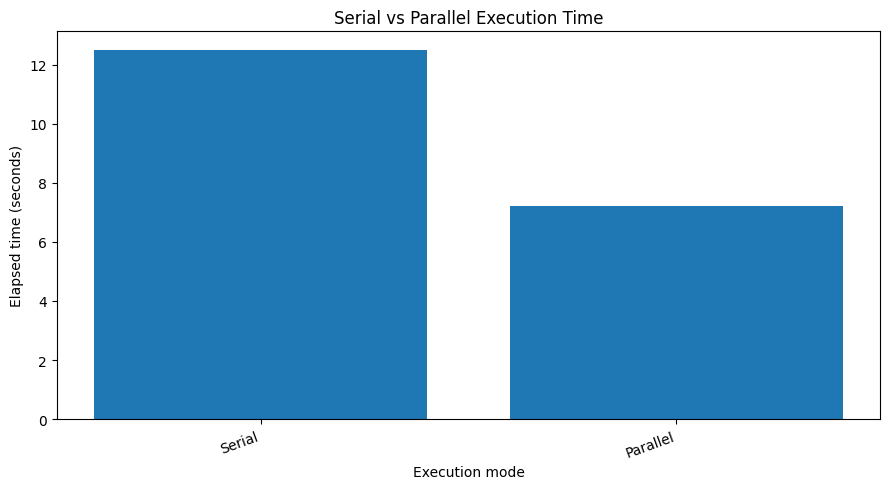

In [ ]:
timing_df = pd.DataFrame({
    'mode': ['Serial', 'Parallel'],
    'elapsed_seconds': [12.5, 7.2]
})

def show_timing_chart(timing_df: pd.DataFrame):
    print("Timing data:")
    print(timing_df.to_string(index=False))

    plt.figure(figsize=(9, 5))
    plt.bar(timing_df['mode'], timing_df['elapsed_seconds'])
    plt.ylabel('Elapsed time (seconds)')
    plt.xlabel('Execution mode')
    plt.title('Serial vs Parallel Execution Time')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

show_timing_chart(timing_df)

In [ ]:
big_df, small_df = load_pandas_data(BIG_FILE, SMALL_FILE)
big_df = clean_big_dataset(big_df)
small_df = clean_small_dataset(small_df)

print(big_df.head())
print(small_df.head())

      Level       Date  State FIPS State Postal Code  County FIPS County Name  \
0  National 2019-01-01         NaN               NaN          NaN         NaN   
1  National 2019-01-02         NaN               NaN          NaN         NaN   
2  National 2019-01-03         NaN               NaN          NaN         NaN   
3  National 2019-01-04         NaN               NaN          NaN         NaN   
4  National 2019-01-05         NaN               NaN          NaN         NaN   

   Population Staying at Home  Population Not Staying at Home  \
0                  77433867.0                     248733553.0   
1                  61305201.0                     264862219.0   
2                  63050480.0                     263116940.0   
3                  61803652.0                     264363768.0   
4                  64389745.0                     261777675.0   

   Number of Trips  Number of Trips <1  ...  Number of Trips 5-10  \
0     8.977844e+08         241667151.0  ...          

In [ ]:
weekly_home, daily_not_home, mean_trips_by_distance = question_1(big_df, small_df)

weekly_home.head(), daily_not_home.head(), mean_trips_by_distance.head()

(   Week  avg_population_staying_home
 0     0                 7.384405e+07
 1     1                 7.222715e+07
 2     2                 7.144295e+07
 3     3                 6.998493e+07
 4     4                 6.982941e+07,
         Date  People Not Staying at Home
 0 2019-08-04                   258404133
 1 2019-08-05                   262199758
 2 2019-08-06                   260096133
 3 2019-08-07                   258878802
 4 2019-08-08                   262410045,
        distance_band    mean_trips
 0    Trips 1-3 Miles  3.694767e+08
 1      Trips <1 Mile  3.259764e+08
 2   Trips 5-10 Miles  2.334445e+08
 3  Trips 10-25 Miles  2.310785e+08
 4    Trips 3-5 Miles  1.815558e+08)

In [ ]:
over_10_25, over_50_100, both, q2_summary = question_2(big_df)

print(q2_summary)
print()
print('Dates above 10,000,000 for 10-25 trips')
print(over_10_25[['Date', 'Number of Trips 10-25']].head())
print()
print('Dates above 10,000,000 for 50-100 trips')
print(over_50_100[['Date', 'Number of Trips 50-100']].head())

                   condition  count
0   10-25 trips > 10,000,000    901
1  50-100 trips > 10,000,000    900
2       Both conditions true    900

Dates above 10,000,000 for 10-25 trips
        Date  Number of Trips 10-25
0 2019-01-01            116904343.0
1 2019-01-02            167412698.0
2 2019-01-03            172027487.0
3 2019-01-04            176144493.0
4 2019-01-05            165239790.0

Dates above 10,000,000 for 50-100 trips
        Date  Number of Trips 50-100
0 2019-01-01              15686639.0
1 2019-01-02              17739183.0
2 2019-01-03              18366626.0
3 2019-01-04              19315785.0
4 2019-01-05              19363939.0


In [ ]:
long_df, metrics, plot_df = question_3(small_df)

print(metrics)

                              model          rmse        r2
0  Polynomial Regression (degree 2)  8.035909e+07  0.691822
1                 Linear Regression  1.058043e+08  0.465758
